## Preliminaries

In [1]:
# pip install matplotlib pandas scikit-learn seaborn

In [2]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

from scipy.stats import kendalltau
from sklearn.metrics import mean_absolute_error

## Data Loading

In [3]:
predictions = pd.read_csv("predictions/fdata/predictions.csv")

In [4]:
w_74k = pd.read_csv('workloads/fdata/fdata.swf', sep="\t", header=None)

workload_column_names = [
    "Job Number", "Submit Time", "Wait Time", "Run Time",
    "Number of Allocated Nodes", "Average CPU Time Used",
    "Used Memory", "Requested Number of Nodes",
    "Requested Time", "Requested Memory", "Status",
    "User ID", "Group ID", "Executable Number",
    "Queue Number", "Partition Number",
    "Preceding Job Number", "Think Time from Preceding Job"
]

w_74k.columns = workload_column_names

predictions["nodes"] = w_74k["Number of Allocated Nodes"]
predictions = predictions.dropna()

In [5]:
predictions

,job_id,user_id,time_submit,gt_runtime,pred_runtime_user,pred_runtime_heuristic,pred_runtime_dt,pred_runtime_rnp,pred_runtime_knn,pred_runtime_llm,nodes
0,8687223,1122,1894043,462,2400,141,424,229,462,572,128
1,8773168,299,1894044,716,3600,523,670,896,691,710,128
2,8688742,299,1894044,1063,3600,523,752,919,708,783,128
3,8773169,299,1894044,721,3600,523,719,914,696,737,128
4,8773159,299,1894044,686,3600,523,703,928,715,704,128
...,...,...,...,...,...,...,...,...,...,...,...
84872,8771078,1214,2432755,658,900,627,900,900,669,694,1
84873,8771098,1214,2432878,659,900,627,900,900,670,658,1
84874,8771099,1214,2432894,665,900,627,900,900,668,664,1
84875,8771789,1775,2433016,1046,10800,10800,1028,581,1207,2658,4


In [6]:
w_18k_1 = pd.read_csv('workloads/fdata/fdata_18k_1.swf', sep="\t", header=None)
w_18k_2 = pd.read_csv('workloads/fdata/fdata_18k_2.swf', sep="\t", header=None)
w_18k_3 = pd.read_csv('workloads/fdata/fdata_18k_3.swf', sep="\t", header=None)
w_18k_4 = pd.read_csv('workloads/fdata/fdata_18k_4.swf', sep="\t", header=None)
w_18k_5 = pd.read_csv('workloads/fdata/fdata_18k_5.swf', sep="\t", header=None)

## Preliminaries

In [7]:
def assign_job_classes(df, runtime_col="gt_runtime", nodes_col="nodes"):

    df = df.copy()
    
    # --- Duration classification
    def duration_class(runtime):
        if 1 <= runtime < 900:
            return "Short"
        elif 900 <= runtime < 21600:
            return "Medium"
        elif 21600 <= runtime <= 259200:
            return "Long"
        else:
            return None

    # --- Size classification
    def size_class(nodes):
        if 1 <= nodes < 1024/200:
            return "Small"
        elif 1024/200 <= nodes < 4096/100*3:
            return "Medium"
        elif 4096/100*3 <= nodes <= 158976:
            return "Large"
        else:
            return None

    # Apply classifications
    df["size_class"] = df[nodes_col].apply(size_class)
    df["duration_class"] = df[runtime_col].apply(duration_class)

    return df


def plot_job_classes(df, runtime_col="gt_runtime", nodes_col="nodes"):

    plt.figure(figsize=(8, 6))

    # -----------------------
    # STYLE MAPS
    # -----------------------
    duration_colors = {
        "Short": "tab:blue",
        "Medium": "tab:orange",
        "Long": "tab:green"
    }

    size_markers = {
        "Small": "o",
        "Medium": "^",
        "Large": "s"
    }

    total_jobs = len(df)

    # -----------------------
    # PLOT COMBINATIONS
    # -----------------------
    for d_class, color in duration_colors.items():
        for s_class, marker in size_markers.items():

            subset = df[
                (df["duration_class"] == d_class) &
                (df["size_class"] == s_class)
            ]

            if subset.empty:
                continue

            count = len(subset)
            perc = (count / total_jobs) * 100 if total_jobs > 0 else 0

            label = f"{d_class} | {s_class} (n={count}, {perc:.1f}%)"

            plt.scatter(
                subset[runtime_col],
                subset[nodes_col],
                color=color,
                marker=marker,
                label=label,
                alpha=0.6,
                s=10
            )

    # -----------------------
    # AXES
    # -----------------------
    ticks = np.arange(0, 259201, 10800)
    plt.xlim(0, max(ticks))
    plt.xticks(ticks=ticks, labels=(ticks / 3600).astype(int))
    plt.axvline(900, linestyle="--", alpha=0.5)
    plt.axvline(21600, linestyle="--", alpha=0.5)
    plt.xlabel("Runtime (hours)")
    
    
    ticks = np.arange(0, 43201, 675*4)
    plt.ylim(0, max(ticks))
    plt.yticks(ticks=ticks, labels=ticks.astype(int))
    plt.axhline(1024, linestyle="--", alpha=0.5)
    plt.axhline(4096, linestyle="--", alpha=0.5)
    plt.ylabel("Nodes")
    
    plt.title("Job Classes (Duration vs Size)")
    plt.grid(True)
    
    # -----------------------
    # LEGEND
    # -----------------------
    # --- duration legend (colors)
    duration_handles = [
        plt.Line2D([0], [0], marker='o', color='w',
                   markerfacecolor=color, markersize=8, label=cls)
        for cls, color in duration_colors.items()
    ]
    
    # --- size legend (markers)
    size_handles = [
        plt.Line2D([0], [0], marker=marker, color='black',
                   linestyle='None', markersize=8, label=cls)
        for cls, marker in size_markers.items()
    ]
    
    # First legend (top-right)
    legend1 = plt.legend(
        handles=duration_handles,
        title="Duration",
        loc="upper left",
        bbox_to_anchor=(1.02, 1.0)
    )
    
    # Second legend (just below first)
    legend2 = plt.legend(
        handles=size_handles,
        title="Size",
        loc="upper left",
        bbox_to_anchor=(1.02, 0.70)  # 👈 adjust if needed
    )
    
    plt.gca().add_artist(legend1)

    plt.show()

        # =======================
    # MATRIX PLOT (PERCENTAGES)
    # =======================
    
    duration_classes = ["Short", "Medium", "Long"]
    size_classes = ["Small", "Medium", "Large"]
    
    # count matrix
    matrix = pd.DataFrame(0, index=duration_classes, columns=size_classes)
    
    for d in duration_classes:
        for s in size_classes:
            matrix.loc[d, s] = len(df[
                (df["duration_class"] == d) &
                (df["size_class"] == s)
            ])
    
    total_jobs = matrix.values.sum()
    
    # convert to percentage
    perc_matrix = (matrix / total_jobs) * 100
    
    # add totals
    perc_matrix["Total"] = perc_matrix.sum(axis=1)
    perc_matrix.loc["Total"] = perc_matrix.sum(axis=0)
    
    # enforce 100% in bottom-right
    perc_matrix.loc["Total", "Total"] = 100.0
    
    # -----------------------
    # PLOT MATRIX
    # -----------------------
    fig, ax = plt.subplots(figsize=(6, 5), constrained_layout=True)
    
    im = ax.imshow(perc_matrix.values, cmap="Blues")
    
    # ticks
    ax.set_xticks(np.arange(len(perc_matrix.columns)))
    ax.set_yticks(np.arange(len(perc_matrix.index)))
    
    ax.set_xticklabels(perc_matrix.columns)
    ax.set_yticklabels(perc_matrix.index)
    
    ax.set_xlabel("Size Class")
    ax.set_ylabel("Duration Class")
    ax.set_title("Job Distribution (%)")
    
    # annotate cells
    for i in range(len(perc_matrix.index)):
        for j in range(len(perc_matrix.columns)):
            val = perc_matrix.iloc[i, j]
            ax.text(j, i, f"{val:.2f}%",
                    ha="center", va="center", color="black")
    
    # colorbar
    cbar = fig.colorbar(im, ax=ax, pad=0.02)
    cbar.set_label("Percentage of Jobs")
    
    plt.show()

In [8]:
predictions = assign_job_classes(predictions)

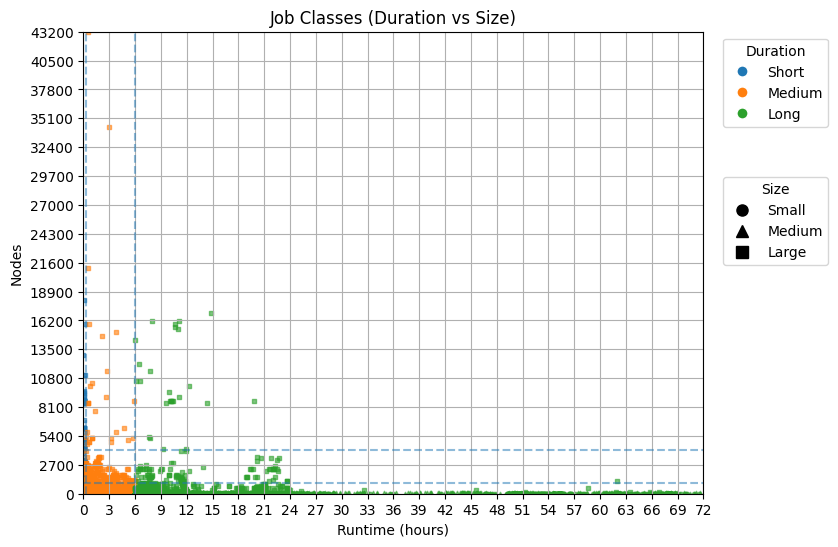

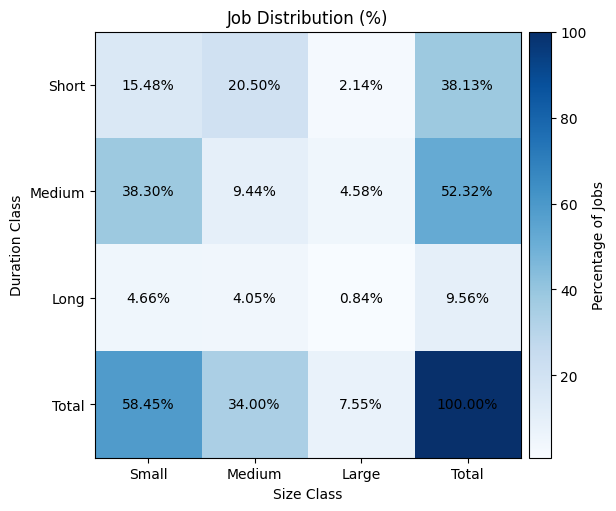

In [9]:
plot_job_classes(predictions)

In [10]:
pred_w_18k_1 = predictions[predictions["job_id"].isin(w_18k_1[0].values)]
pred_w_18k_2 = predictions[predictions["job_id"].isin(w_18k_2[0].values)]
pred_w_18k_3 = predictions[predictions["job_id"].isin(w_18k_3[0].values)]
pred_w_18k_4 = predictions[predictions["job_id"].isin(w_18k_4[0].values)]
pred_w_18k_5 = predictions[predictions["job_id"].isin(w_18k_5[0].values)]

In [11]:
max(predictions.time_submit) - min(predictions.time_submit) 

538975

## Metrics Helpers

In [12]:
def mean_average_percentage_error(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Avoid division by zero
    mask = (y_true > 0) & (y_pred > 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]
    
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mape

In [13]:
def estimation_accuracy(y_true, y_pred):
    y_true = np.array(y_true, dtype=float)
    y_pred = np.array(y_pred, dtype=float)

    # Avoid division by zero
    mask = (y_true > 0) & (y_pred > 0)
    y_true = y_true[mask]
    y_pred = y_pred[mask]

    ea = np.where(y_pred <= y_true,
                  y_pred / y_true,
                  y_true / y_pred)

    return float(np.mean(ea))

In [14]:
def convert_to_hms(time_value, unit="seconds"):
    if unit == "minutes":
        time_value *= 60  # Convert minutes to seconds
    hours, remainder = divmod(time_value, 3600)
    minutes, seconds = divmod(remainder, 60)
    return f"{int(hours):02}:{int(minutes):02}:{int(seconds):02}"

In [15]:
def compute_error_metrics(df, pred_col, gt_col="gt_runtime"):
    err = df[pred_col] - df[gt_col]

    over = err[err > 0]
    exact = err[err == 0]
    under = err[err < 0]

    mae_over = over.mean() if len(over) > 0 else 0
    mae_under = np.abs(under.mean()) if len(under) > 0 else 0

    PJO = len(over) / len(err)
    PJE = len(exact) / len(err)
    PJU = len(under) / len(err)

    return mae_over, mae_under, PJO, PJU, PJE

In [16]:
def compute_metrics_per_class(df, pred_col, gt_col="gt_runtime"):

    results = {}

    for cls in df["duration_class"].unique():
        subset = df[df["duration_class"] == cls]

        err = subset[pred_col] - subset[gt_col]

        over = err[err > 0]
        exact = err[err == 0]
        under = err[err < 0]
        
        if len(subset) == 0:
            results[f"MAE_{cls[0]}"] = np.nan
            results[f"PJO_{cls[0]}"] = np.nan
            results[f"PJE_{cls[0]}"] = np.nan
            results[f"PJU_{cls[0]}"] = np.nan
        else:
            results[f"MAE_{cls[0]}"] = mean_absolute_error(subset[gt_col], subset[pred_col])
            results[f"MAE_OVER_{cls[0]}"] = over.mean() if len(over) > 0 else 0
            results[f"MAE_UNDER_{cls[0]}"] = np.abs(under.mean()) if len(under) > 0 else 0
            results[f"PJO_{cls[0]}"] = len(over) / len(err)
            results[f"PJE_{cls[0]}"] = len(exact) / len(err)
            results[f"PJU_{cls[0]}"] = len(under) / len(err)

    return results['MAE_S'], results['MAE_OVER_S'], results['MAE_UNDER_S'], results['PJO_S'], results['PJE_S'], results['PJU_S'], results['MAE_M'], results['MAE_OVER_M'], results['MAE_UNDER_M'], results['PJO_M'], results['PJE_M'], results['PJU_M'], results['MAE_L'], results['MAE_OVER_L'], results['MAE_UNDER_L'], results['PJO_L'], results['PJE_L'], results['PJU_L']

In [17]:
# gt_runtime pred_runtime_user pred_runtime_heuristic pred_runtime_dt pred_runtime_rnp pred_runtime_knn pred_runtime_llm

## Complete Dataset

### Metric Computation

In [20]:
mae_usr = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_user)
mae_heu = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_heuristic)
mae_dt  = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_dt)
mae_rnp = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_rnp)
mae_knn = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_knn)
mae_llm = mean_absolute_error(predictions.gt_runtime, predictions.pred_runtime_llm)

In [21]:
ea_usr = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_user)
ea_heu = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_heuristic)
ea_dt  = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_dt)
ea_rnp = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_rnp)
ea_knn = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_knn)
ea_llm = estimation_accuracy(predictions.gt_runtime, predictions.pred_runtime_llm)

In [22]:
mape_usr = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_user)
mape_heu = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_heuristic)
mape_dt  = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_dt)
mape_rnp = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_rnp)
mape_knn = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_knn)
mape_llm = mean_average_percentage_error(predictions.gt_runtime, predictions.pred_runtime_llm)

In [23]:
tau_usr, _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_user)
tau_heu, _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_heuristic)
tau_dt , _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_dt)
tau_rnp, _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_rnp)
tau_knn, _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_knn)
tau_llm, _ = kendalltau(predictions.gt_runtime, predictions.pred_runtime_llm)

In [24]:
mae_over_usr, mae_under_usr, pjo_usr, pju_usr, pje_usr = compute_error_metrics(predictions, "pred_runtime_user")
mae_over_act, mae_under_act, pjo_act, pju_act, pje_act = compute_error_metrics(predictions, "gt_runtime")
mae_over_heu, mae_under_heu, pjo_heu, pju_heu, pje_heu = compute_error_metrics(predictions, "pred_runtime_heuristic")
mae_over_dt, mae_under_dt, pjo_dt, pju_dt, pje_dt = compute_error_metrics(predictions, "pred_runtime_dt")
mae_over_rnp, mae_under_rnp, pjo_rnp, pju_rnp, pje_rnp = compute_error_metrics(predictions, "pred_runtime_rnp")
mae_over_knn, mae_under_knn, pjo_knn, pju_knn, pje_knn = compute_error_metrics(predictions, "pred_runtime_knn")
mae_over_llm, mae_under_llm, pjo_llm, pju_llm, pje_llm = compute_error_metrics(predictions, "pred_runtime_llm")

In [25]:
mae_s_usr, mae_over_s_usr, mae_under_s_usr, pjo_s_usr, pje_s_usr, pju_s_usr, mae_m_usr, mae_over_m_usr, mae_under_m_usr, pjo_m_usr, pje_m_usr, pju_m_usr, mae_l_usr, mae_over_l_usr, mae_under_l_usr, pjo_l_usr, pje_l_usr, pju_l_usr = compute_metrics_per_class(predictions, "pred_runtime_user")
mae_s_heu, mae_over_s_heu, mae_under_s_heu, pjo_s_heu, pje_s_heu, pju_s_heu, mae_m_heu, mae_over_m_heu, mae_under_m_heu, pjo_m_heu, pje_m_heu, pju_m_heu, mae_l_heu, mae_over_l_heu, mae_under_l_heu, pjo_l_heu, pje_l_heu, pju_l_heu = compute_metrics_per_class(predictions, "pred_runtime_heuristic")
mae_s_dt, mae_over_s_dt, mae_under_s_dt, pjo_s_dt, pje_s_dt, pju_s_dt, mae_m_dt, mae_over_m_dt, mae_under_m_dt, pjo_m_dt, pje_m_dt, pju_m_dt, mae_l_dt, mae_over_l_dt, mae_under_l_dt, pjo_l_dt, pje_l_dt, pju_l_dt = compute_metrics_per_class(predictions, "pred_runtime_dt")
mae_s_rnp, mae_over_s_rnp, mae_under_s_rnp, pjo_s_rnp, pje_s_rnp, pju_s_rnp, mae_m_rnp, mae_over_m_rnp, mae_under_m_rnp, pjo_m_rnp, pje_m_rnp, pju_m_rnp, mae_l_rnp, mae_over_l_rnp, mae_under_l_rnp, pjo_l_rnp, pje_l_rnp, pju_l_rnp = compute_metrics_per_class(predictions, "pred_runtime_rnp")
mae_s_knn, mae_over_s_knn, mae_under_s_knn, pjo_s_knn, pje_s_knn, pju_s_knn, mae_m_knn, mae_over_m_knn, mae_under_m_knn, pjo_m_knn, pje_m_knn, pju_m_knn, mae_l_knn, mae_over_l_knn, mae_under_l_knn, pjo_l_knn, pje_l_knn, pju_l_knn = compute_metrics_per_class(predictions, "pred_runtime_knn")
mae_s_llm, mae_over_s_llm, mae_under_s_llm, pjo_s_llm, pje_s_llm, pju_s_llm, mae_m_llm, mae_over_m_llm, mae_under_m_llm, pjo_m_llm, pje_m_llm, pju_m_llm, mae_l_llm, mae_over_l_llm, mae_under_l_llm, pjo_l_llm, pje_l_llm, pju_l_llm = compute_metrics_per_class(predictions, "pred_runtime_llm")

### Details

In [26]:
res = pd.DataFrame()
res['Workload'] = ('Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal', 'Normal')
res['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res['Average Error'] = (convert_to_hms(mae_usr), convert_to_hms(0), convert_to_hms(mae_heu), convert_to_hms(mae_dt), convert_to_hms(mae_rnp), convert_to_hms(mae_knn), convert_to_hms(mae_llm))
res['MAE'] = (mae_usr, 0, mae_heu, mae_dt, mae_rnp, mae_knn, mae_llm)
res['MAPE'] = (mape_usr/1000, 0, mape_heu/1000, mape_dt/1000, mape_rnp/1000, mape_knn/1000, mape_llm/1000)
res['EA'] = (ea_usr, 1, ea_heu, ea_dt, ea_rnp, ea_knn, ea_llm)
res['TAU'] = (tau_usr, 1, tau_heu, tau_dt, tau_rnp, tau_knn, tau_llm)

res["MAE_OVER"] = (mae_over_usr, 0, mae_over_heu, mae_over_dt, mae_over_rnp, mae_over_knn, mae_over_llm)
res["MAE_UNDER"] = (mae_under_usr, 0, mae_under_heu, mae_under_dt, mae_under_rnp, mae_under_knn, mae_under_llm)

res["%_OVER"] = (pjo_usr, pjo_act, pjo_heu, pjo_dt, pjo_rnp, pjo_knn, pjo_llm)
res["%_UNDER"] = (pju_usr, pjo_act, pju_heu, pju_dt, pju_rnp, pju_knn, pju_llm)
res["%_EXACT"] = (pje_usr, pje_act, pje_heu, pje_dt, pje_rnp, pje_knn, pje_llm)

# ------------------------------------------------------------------------------------------------------------------------ #

res['MAE_S'] = (mae_s_usr, 0, mae_s_heu, mae_s_dt, mae_s_rnp, mae_s_knn, mae_s_llm)
res["MAE_OVER_S"] = (mae_over_s_usr, 0, mae_over_s_heu, mae_over_s_dt, mae_over_s_rnp, mae_over_s_knn, mae_over_s_llm)
res["MAE_UNDER_S"] = (mae_under_s_usr, 0, mae_under_s_heu, mae_under_s_dt, mae_under_s_rnp, mae_under_s_knn, mae_under_s_llm)

res["%_OVER_S"] = (pjo_s_usr, 0, pjo_s_heu, pjo_s_dt, pjo_s_rnp, pjo_s_knn, pjo_s_llm)
res["%_UNDER_S"] = (pju_s_usr, 0, pju_s_heu, pju_s_dt, pju_s_rnp, pju_s_knn, pju_s_llm)
res["%_EXACT_S"] = (pje_s_usr, 1, pje_s_heu, pje_s_dt, pje_s_rnp, pje_s_knn, pje_s_llm)

res['MAE_M'] = (mae_m_usr, 0, mae_m_heu, mae_m_dt, mae_m_rnp, mae_m_knn, mae_llm)
res["MAE_OVER_M"] = (mae_over_m_usr, 0, mae_over_m_heu, mae_over_m_dt, mae_over_m_rnp, mae_over_m_knn, mae_over_m_llm)
res["MAE_UNDER_M"] = (mae_under_m_usr, 0, mae_under_m_heu, mae_under_m_dt, mae_under_m_rnp, mae_under_m_knn, mae_under_m_llm)

res["%_OVER_M"] = (pjo_m_usr, 0, pjo_m_heu, pjo_m_dt, pjo_m_rnp, pjo_m_knn, pjo_m_llm)
res["%_UNDER_M"] = (pju_m_usr, 0, pju_m_heu, pju_m_dt, pju_m_rnp, pju_m_knn, pju_m_llm)
res["%_EXACT_M"] = (pje_m_usr, 1, pje_m_heu, pje_m_dt, pje_m_rnp, pje_m_knn, pje_m_llm)

res['MAE_L'] = (mae_l_usr, 0, mae_l_heu, mae_l_dt, mae_l_rnp, mae_l_knn, mae_l_llm)
res["MAE_OVER_L"] = (mae_over_l_usr, 0, mae_over_l_heu, mae_over_l_dt, mae_over_l_rnp, mae_over_l_knn, mae_over_l_llm)
res["MAE_UNDER_L"] = (mae_under_l_usr, 0, mae_under_l_heu, mae_under_l_dt, mae_under_l_rnp, mae_under_l_knn, mae_under_l_llm)

res["%_OVER_L"] = (pjo_l_usr, 0, pjo_l_heu, pjo_l_dt, pjo_l_rnp, pjo_l_knn, pjo_l_llm)
res["%_UNDER_L"] = (pju_l_usr, 0, pju_l_heu, pju_l_dt, pju_l_rnp, pju_l_knn, pju_l_llm)
res["%_EXACT_L"] = (pje_l_usr, 1, pje_l_heu, pje_l_dt, pje_l_rnp, pje_l_knn, pje_l_llm)

res

,Workload,Estimation,Average Error,MAE,MAPE,EA,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Normal,1 - User,03:37:09,13029.479765,16.601188,0.415831,0.680331,13029.479765,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,31274.081741,31274.081741,0.000000,1.000000,0.000000,0.000000
1,Normal,2 - Actual,00:00:00,0.000000,0.000000,1.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Normal,3 - Heuristic,01:14:20,4460.031764,5.703228,0.530634,0.603519,2579.514142,7017.600699,0.573595,...,5053.086169,0.464982,0.534703,0.000315,18223.941438,6626.750746,22962.049479,0.289360,0.710147,0.000493
3,Normal,4 - DT,00:46:55,2815.974917,1.183033,0.686089,0.740495,2143.232952,3775.334171,0.454729,...,1596.533752,0.404990,0.505742,0.089267,17734.107878,8984.276994,22497.131889,0.349402,0.648749,0.001849
4,Normal,5 - RNP,00:56:08,3368.112539,2.080358,0.633499,0.682250,3987.707388,2969.001551,0.471412,...,1334.818917,0.419515,0.532135,0.048349,17853.124399,14423.936399,20633.836794,0.447787,0.552213,0.000000
5,Normal,6 - KNN,00:38:41,2321.614112,4.240325,0.732360,0.797935,2146.390022,2723.333767,0.403820,...,1721.872373,0.201369,0.695379,0.103252,10270.480089,5264.876313,12593.477798,0.316977,0.683023,0.000000
6,Normal,7 - LLM,00:28:18,1698.660250,2.019833,0.852412,0.862187,2463.743289,2347.133175,0.382259,...,1982.356734,0.393032,0.361843,0.245125,5209.899026,3415.739378,9414.760870,0.368512,0.419677,0.211811


In [27]:
res.to_csv("results/fdata_metrics.csv", index=False)

## F-DATA - Heavy Workloads

### Metric Computation

In [28]:
mae_usr_h1 = mean_absolute_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_user)
mae_heu_h1 = mean_absolute_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_heuristic)
mae_dt_h1  = mean_absolute_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_dt)
mae_rnp_h1 = mean_absolute_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_rnp)
mae_knn_h1 = mean_absolute_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_knn)
mae_llm_h1 = mean_absolute_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_llm)

mae_usr_h2 = mean_absolute_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_user)
mae_heu_h2 = mean_absolute_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_heuristic)
mae_dt_h2  = mean_absolute_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_dt)
mae_rnp_h2 = mean_absolute_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_rnp)
mae_knn_h2 = mean_absolute_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_knn)
mae_llm_h2 = mean_absolute_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_llm)

mae_usr_h3 = mean_absolute_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_user)
mae_heu_h3 = mean_absolute_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_heuristic)
mae_dt_h3  = mean_absolute_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_dt)
mae_rnp_h3 = mean_absolute_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_rnp)
mae_knn_h3 = mean_absolute_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_knn)
mae_llm_h3 = mean_absolute_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_llm)

mae_usr_h4 = mean_absolute_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_user)
mae_heu_h4 = mean_absolute_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_heuristic)
mae_dt_h4  = mean_absolute_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_dt)
mae_rnp_h4 = mean_absolute_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_rnp)
mae_knn_h4 = mean_absolute_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_knn)
mae_llm_h4 = mean_absolute_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_llm)

mae_usr_h5 = mean_absolute_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_user)
mae_heu_h5 = mean_absolute_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_heuristic)
mae_dt_h5  = mean_absolute_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_dt)
mae_rnp_h5 = mean_absolute_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_rnp)
mae_knn_h5 = mean_absolute_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_knn)
mae_llm_h5 = mean_absolute_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_llm)

In [29]:
ea_usr_h1 = estimation_accuracy(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_user)
ea_heu_h1 = estimation_accuracy(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_heuristic)
ea_dt_h1  = estimation_accuracy(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_dt)
ea_rnp_h1 = estimation_accuracy(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_rnp)
ea_knn_h1 = estimation_accuracy(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_knn)
ea_llm_h1 = estimation_accuracy(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_llm)

ea_usr_h2 = estimation_accuracy(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_user)
ea_heu_h2 = estimation_accuracy(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_heuristic)
ea_dt_h2  = estimation_accuracy(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_dt)
ea_rnp_h2 = estimation_accuracy(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_rnp)
ea_knn_h2 = estimation_accuracy(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_knn)
ea_llm_h2 = estimation_accuracy(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_llm)

ea_usr_h3 = estimation_accuracy(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_user)
ea_heu_h3 = estimation_accuracy(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_heuristic)
ea_dt_h3  = estimation_accuracy(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_dt)
ea_rnp_h3 = estimation_accuracy(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_rnp)
ea_knn_h3 = estimation_accuracy(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_knn)
ea_llm_h3 = estimation_accuracy(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_llm)

ea_usr_h4 = estimation_accuracy(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_user)
ea_heu_h4 = estimation_accuracy(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_heuristic)
ea_dt_h4  = estimation_accuracy(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_dt)
ea_rnp_h4 = estimation_accuracy(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_rnp)
ea_knn_h4 = estimation_accuracy(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_knn)
ea_llm_h4 = estimation_accuracy(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_llm)

ea_usr_h5 = estimation_accuracy(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_user)
ea_heu_h5 = estimation_accuracy(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_heuristic)
ea_dt_h5  = estimation_accuracy(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_dt)
ea_rnp_h5 = estimation_accuracy(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_rnp)
ea_knn_h5 = estimation_accuracy(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_knn)
ea_llm_h5 = estimation_accuracy(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_llm)

In [30]:
mape_usr_h1 = mean_average_percentage_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_user)
mape_heu_h1 = mean_average_percentage_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_heuristic)
mape_dt_h1  = mean_average_percentage_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_dt)
mape_rnp_h1 = mean_average_percentage_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_rnp)
mape_knn_h1 = mean_average_percentage_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_knn)
mape_llm_h1 = mean_average_percentage_error(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_llm)

mape_usr_h2 = mean_average_percentage_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_user)
mape_heu_h2 = mean_average_percentage_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_heuristic)
mape_dt_h2  = mean_average_percentage_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_dt)
mape_rnp_h2 = mean_average_percentage_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_rnp)
mape_knn_h2 = mean_average_percentage_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_knn)
mape_llm_h2 = mean_average_percentage_error(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_llm)

mape_usr_h3 = mean_average_percentage_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_user)
mape_heu_h3 = mean_average_percentage_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_heuristic)
mape_dt_h3  = mean_average_percentage_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_dt)
mape_rnp_h3 = mean_average_percentage_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_rnp)
mape_knn_h3 = mean_average_percentage_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_knn)
mape_llm_h3 = mean_average_percentage_error(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_llm)

mape_usr_h4 = mean_average_percentage_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_user)
mape_heu_h4 = mean_average_percentage_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_heuristic)
mape_dt_h4  = mean_average_percentage_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_dt)
mape_rnp_h4 = mean_average_percentage_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_rnp)
mape_knn_h4 = mean_average_percentage_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_knn)
mape_llm_h4 = mean_average_percentage_error(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_llm)

mape_usr_h5 = mean_average_percentage_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_user)
mape_heu_h5 = mean_average_percentage_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_heuristic)
mape_dt_h5  = mean_average_percentage_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_dt)
mape_rnp_h5 = mean_average_percentage_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_rnp)
mape_knn_h5 = mean_average_percentage_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_knn)
mape_llm_h5 = mean_average_percentage_error(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_llm)

In [31]:
tau_usr_h1, _ = kendalltau(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_user)
tau_heu_h1, _ = kendalltau(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_heuristic)
tau_dt_h1 , _ = kendalltau(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_dt)
tau_rnp_h1, _ = kendalltau(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_rnp)
tau_knn_h1, _ = kendalltau(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_knn)
tau_llm_h1, _ = kendalltau(pred_w_18k_1.gt_runtime, pred_w_18k_1.pred_runtime_llm)

tau_usr_h2, _ = kendalltau(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_user)
tau_heu_h2, _ = kendalltau(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_heuristic)
tau_dt_h2 , _ = kendalltau(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_dt)
tau_rnp_h2, _ = kendalltau(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_rnp)
tau_knn_h2, _ = kendalltau(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_knn)
tau_llm_h2, _ = kendalltau(pred_w_18k_2.gt_runtime, pred_w_18k_2.pred_runtime_llm)

tau_usr_h3, _ = kendalltau(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_user)
tau_heu_h3, _ = kendalltau(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_heuristic)
tau_dt_h3 , _ = kendalltau(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_dt)
tau_rnp_h3, _ = kendalltau(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_rnp)
tau_knn_h3, _ = kendalltau(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_knn)
tau_llm_h3, _ = kendalltau(pred_w_18k_3.gt_runtime, pred_w_18k_3.pred_runtime_llm)

tau_usr_h4, _ = kendalltau(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_user)
tau_heu_h4, _ = kendalltau(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_heuristic)
tau_dt_h4 , _ = kendalltau(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_dt)
tau_rnp_h4, _ = kendalltau(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_rnp)
tau_knn_h4, _ = kendalltau(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_knn)
tau_llm_h4, _ = kendalltau(pred_w_18k_4.gt_runtime, pred_w_18k_4.pred_runtime_llm)

tau_usr_h5, _ = kendalltau(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_user)
tau_heu_h5, _ = kendalltau(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_heuristic)
tau_dt_h5 , _ = kendalltau(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_dt)
tau_rnp_h5, _ = kendalltau(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_rnp)
tau_knn_h5, _ = kendalltau(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_knn)
tau_llm_h5, _ = kendalltau(pred_w_18k_5.gt_runtime, pred_w_18k_5.pred_runtime_llm)

In [32]:
mae_over_usr_h1, mae_under_usr_h1, pjo_usr_h1, pju_usr_h1, pje_usr_h1 = compute_error_metrics(pred_w_18k_1, "pred_runtime_user")
mae_over_act_h1, mae_under_act_h1, pjo_act_h1, pju_act_h1, pje_act_h1 = compute_error_metrics(pred_w_18k_1, "gt_runtime")
mae_over_heu_h1, mae_under_heu_h1, pjo_heu_h1, pju_heu_h1, pje_heu_h1 = compute_error_metrics(pred_w_18k_1, "pred_runtime_heuristic")
mae_over_dt_h1, mae_under_dt_h1, pjo_dt_h1, pju_dt_h1, pje_dt_h1 = compute_error_metrics(pred_w_18k_1, "pred_runtime_dt")
mae_over_rnp_h1, mae_under_rnp_h1, pjo_rnp_h1, pju_rnp_h1, pje_rnp_h1 = compute_error_metrics(pred_w_18k_1, "pred_runtime_rnp")
mae_over_knn_h1, mae_under_knn_h1, pjo_knn_h1, pju_knn_h1, pje_knn_h1 = compute_error_metrics(pred_w_18k_1, "pred_runtime_knn")
mae_over_llm_h1, mae_under_llm_h1, pjo_llm_h1, pju_llm_h1, pje_llm_h1 = compute_error_metrics(pred_w_18k_1, "pred_runtime_llm")

mae_over_usr_h2, mae_under_usr_h2, pjo_usr_h2, pju_usr_h2, pje_usr_h2 = compute_error_metrics(pred_w_18k_2, "pred_runtime_user")
mae_over_act_h2, mae_under_act_h2, pjo_act_h2, pju_act_h2, pje_act_h2 = compute_error_metrics(pred_w_18k_2, "gt_runtime")
mae_over_heu_h2, mae_under_heu_h2, pjo_heu_h2, pju_heu_h2, pje_heu_h2 = compute_error_metrics(pred_w_18k_2, "pred_runtime_heuristic")
mae_over_dt_h2, mae_under_dt_h2, pjo_dt_h2, pju_dt_h2, pje_dt_h2 = compute_error_metrics(pred_w_18k_2, "pred_runtime_dt")
mae_over_rnp_h2, mae_under_rnp_h2, pjo_rnp_h2, pju_rnp_h2, pje_rnp_h2 = compute_error_metrics(pred_w_18k_2, "pred_runtime_rnp")
mae_over_knn_h2, mae_under_knn_h2, pjo_knn_h2, pju_knn_h2, pje_knn_h2 = compute_error_metrics(pred_w_18k_2, "pred_runtime_knn")
mae_over_llm_h2, mae_under_llm_h2, pjo_llm_h2, pju_llm_h2, pje_llm_h2 = compute_error_metrics(pred_w_18k_2, "pred_runtime_llm")

mae_over_usr_h3, mae_under_usr_h3, pjo_usr_h3, pju_usr_h3, pje_usr_h3 = compute_error_metrics(pred_w_18k_3, "pred_runtime_user")
mae_over_act_h3, mae_under_act_h3, pjo_act_h3, pju_act_h3, pje_act_h3 = compute_error_metrics(pred_w_18k_3, "gt_runtime")
mae_over_heu_h3, mae_under_heu_h3, pjo_heu_h3, pju_heu_h3, pje_heu_h3 = compute_error_metrics(pred_w_18k_3, "pred_runtime_heuristic")
mae_over_dt_h3, mae_under_dt_h3, pjo_dt_h3, pju_dt_h3, pje_dt_h3 = compute_error_metrics(pred_w_18k_3, "pred_runtime_dt")
mae_over_rnp_h3, mae_under_rnp_h3, pjo_rnp_h3, pju_rnp_h3, pje_rnp_h3 = compute_error_metrics(pred_w_18k_3, "pred_runtime_rnp")
mae_over_knn_h3, mae_under_knn_h3, pjo_knn_h3, pju_knn_h3, pje_knn_h3 = compute_error_metrics(pred_w_18k_3, "pred_runtime_knn")
mae_over_llm_h3, mae_under_llm_h3, pjo_llm_h3, pju_llm_h3, pje_llm_h3 = compute_error_metrics(pred_w_18k_3, "pred_runtime_llm")

mae_over_usr_h4, mae_under_usr_h4, pjo_usr_h4, pju_usr_h4, pje_usr_h4 = compute_error_metrics(pred_w_18k_4, "pred_runtime_user")
mae_over_act_h4, mae_under_act_h4, pjo_act_h4, pju_act_h4, pje_act_h4 = compute_error_metrics(pred_w_18k_4, "gt_runtime")
mae_over_heu_h4, mae_under_heu_h4, pjo_heu_h4, pju_heu_h4, pje_heu_h4 = compute_error_metrics(pred_w_18k_4, "pred_runtime_heuristic")
mae_over_dt_h4, mae_under_dt_h4, pjo_dt_h4, pju_dt_h4, pje_dt_h4 = compute_error_metrics(pred_w_18k_4, "pred_runtime_dt")
mae_over_rnp_h4, mae_under_rnp_h4, pjo_rnp_h4, pju_rnp_h4, pje_rnp_h4 = compute_error_metrics(pred_w_18k_4, "pred_runtime_rnp")
mae_over_knn_h4, mae_under_knn_h4, pjo_knn_h4, pju_knn_h4, pje_knn_h4 = compute_error_metrics(pred_w_18k_4, "pred_runtime_knn")
mae_over_llm_h4, mae_under_llm_h4, pjo_llm_h4, pju_llm_h4, pje_llm_h4 = compute_error_metrics(pred_w_18k_4, "pred_runtime_llm")

mae_over_usr_h5, mae_under_usr_h5, pjo_usr_h5, pju_usr_h5, pje_usr_h5 = compute_error_metrics(pred_w_18k_5, "pred_runtime_user")
mae_over_act_h5, mae_under_act_h5, pjo_act_h5, pju_act_h5, pje_act_h5 = compute_error_metrics(pred_w_18k_5, "gt_runtime")
mae_over_heu_h5, mae_under_heu_h5, pjo_heu_h5, pju_heu_h5, pje_heu_h5 = compute_error_metrics(pred_w_18k_5, "pred_runtime_heuristic")
mae_over_dt_h5, mae_under_dt_h5, pjo_dt_h5, pju_dt_h5, pje_dt_h5 = compute_error_metrics(pred_w_18k_5, "pred_runtime_dt")
mae_over_rnp_h5, mae_under_rnp_h5, pjo_rnp_h5, pju_rnp_h5, pje_rnp_h5 = compute_error_metrics(pred_w_18k_5, "pred_runtime_rnp")
mae_over_knn_h5, mae_under_knn_h5, pjo_knn_h5, pju_knn_h5, pje_knn_h5 = compute_error_metrics(pred_w_18k_5, "pred_runtime_knn")
mae_over_llm_h5, mae_under_llm_h5, pjo_llm_h5, pju_llm_h5, pje_llm_h5 = compute_error_metrics(pred_w_18k_5, "pred_runtime_llm")

In [33]:
mae_s_usr_h1, mae_over_s_usr_h1, mae_under_s_usr_h1, pjo_s_usr_h1, pje_s_usr_h1, pju_s_usr_h1, mae_m_usr_h1, mae_over_m_usr_h1, mae_under_m_usr_h1, pjo_m_usr_h1, pje_m_usr_h1, pju_m_usr_h1, mae_l_usr_h1, mae_over_l_usr_h1, mae_under_l_usr_h1, pjo_l_usr_h1, pje_l_usr_h1, pju_l_usr_h1 = compute_metrics_per_class(pred_w_18k_1, "pred_runtime_user")
mae_s_heu_h1, mae_over_s_heu_h1, mae_under_s_heu_h1, pjo_s_heu_h1, pje_s_heu_h1, pju_s_heu_h1, mae_m_heu_h1, mae_over_m_heu_h1, mae_under_m_heu_h1, pjo_m_heu_h1, pje_m_heu_h1, pju_m_heu_h1, mae_l_heu_h1, mae_over_l_heu_h1, mae_under_l_heu_h1, pjo_l_heu_h1, pje_l_heu_h1, pju_l_heu_h1 = compute_metrics_per_class(pred_w_18k_1, "pred_runtime_heuristic")
mae_s_dt_h1, mae_over_s_dt_h1, mae_under_s_dt_h1, pjo_s_dt_h1, pje_s_dt_h1, pju_s_dt_h1, mae_m_dt_h1, mae_over_m_dt_h1, mae_under_m_dt_h1, pjo_m_dt_h1, pje_m_dt_h1, pju_m_dt_h1, mae_l_dt_h1, mae_over_l_dt_h1, mae_under_l_dt_h1, pjo_l_dt_h1, pje_l_dt_h1, pju_l_dt_h1 = compute_metrics_per_class(pred_w_18k_1, "pred_runtime_dt")
mae_s_rnp_h1, mae_over_s_rnp_h1, mae_under_s_rnp_h1, pjo_s_rnp_h1, pje_s_rnp_h1, pju_s_rnp_h1, mae_m_rnp_h1, mae_over_m_rnp_h1, mae_under_m_rnp_h1, pjo_m_rnp_h1, pje_m_rnp_h1, pju_m_rnp_h1, mae_l_rnp_h1, mae_over_l_rnp_h1, mae_under_l_rnp_h1, pjo_l_rnp_h1, pje_l_rnp_h1, pju_l_rnp_h1 = compute_metrics_per_class(pred_w_18k_1, "pred_runtime_rnp")
mae_s_knn_h1, mae_over_s_knn_h1, mae_under_s_knn_h1, pjo_s_knn_h1, pje_s_knn_h1, pju_s_knn_h1, mae_m_knn_h1, mae_over_m_knn_h1, mae_under_m_knn_h1, pjo_m_knn_h1, pje_m_knn_h1, pju_m_knn_h1, mae_l_knn_h1, mae_over_l_knn_h1, mae_under_l_knn_h1, pjo_l_knn_h1, pje_l_knn_h1, pju_l_knn_h1 = compute_metrics_per_class(pred_w_18k_1, "pred_runtime_knn")
mae_s_llm_h1, mae_over_s_llm_h1, mae_under_s_llm_h1, pjo_s_llm_h1, pje_s_llm_h1, pju_s_llm_h1, mae_m_llm_h1, mae_over_m_llm_h1, mae_under_m_llm_h1, pjo_m_llm_h1, pje_m_llm_h1, pju_m_llm_h1, mae_l_llm_h1, mae_over_l_llm_h1, mae_under_l_llm_h1, pjo_l_llm_h1, pje_l_llm_h1, pju_l_llm_h1 = compute_metrics_per_class(pred_w_18k_1, "pred_runtime_llm")

mae_s_usr_h2, mae_over_s_usr_h2, mae_under_s_usr_h2, pjo_s_usr_h2, pje_s_usr_h2, pju_s_usr_h2, mae_m_usr_h2, mae_over_m_usr_h2, mae_under_m_usr_h2, pjo_m_usr_h2, pje_m_usr_h2, pju_m_usr_h2, mae_l_usr_h2, mae_over_l_usr_h2, mae_under_l_usr_h2, pjo_l_usr_h2, pje_l_usr_h2, pju_l_usr_h2 = compute_metrics_per_class(pred_w_18k_2, "pred_runtime_user")
mae_s_heu_h2, mae_over_s_heu_h2, mae_under_s_heu_h2, pjo_s_heu_h2, pje_s_heu_h2, pju_s_heu_h2, mae_m_heu_h2, mae_over_m_heu_h2, mae_under_m_heu_h2, pjo_m_heu_h2, pje_m_heu_h2, pju_m_heu_h2, mae_l_heu_h2, mae_over_l_heu_h2, mae_under_l_heu_h2, pjo_l_heu_h2, pje_l_heu_h2, pju_l_heu_h2 = compute_metrics_per_class(pred_w_18k_2, "pred_runtime_heuristic")
mae_s_dt_h2, mae_over_s_dt_h2, mae_under_s_dt_h2, pjo_s_dt_h2, pje_s_dt_h2, pju_s_dt_h2, mae_m_dt_h2, mae_over_m_dt_h2, mae_under_m_dt_h2, pjo_m_dt_h2, pje_m_dt_h2, pju_m_dt_h2, mae_l_dt_h2, mae_over_l_dt_h2, mae_under_l_dt_h2, pjo_l_dt_h2, pje_l_dt_h2, pju_l_dt_h2 = compute_metrics_per_class(pred_w_18k_2, "pred_runtime_dt")
mae_s_rnp_h2, mae_over_s_rnp_h2, mae_under_s_rnp_h2, pjo_s_rnp_h2, pje_s_rnp_h2, pju_s_rnp_h2, mae_m_rnp_h2, mae_over_m_rnp_h2, mae_under_m_rnp_h2, pjo_m_rnp_h2, pje_m_rnp_h2, pju_m_rnp_h2, mae_l_rnp_h2, mae_over_l_rnp_h2, mae_under_l_rnp_h2, pjo_l_rnp_h2, pje_l_rnp_h2, pju_l_rnp_h2 = compute_metrics_per_class(pred_w_18k_2, "pred_runtime_rnp")
mae_s_knn_h2, mae_over_s_knn_h2, mae_under_s_knn_h2, pjo_s_knn_h2, pje_s_knn_h2, pju_s_knn_h2, mae_m_knn_h2, mae_over_m_knn_h2, mae_under_m_knn_h2, pjo_m_knn_h2, pje_m_knn_h2, pju_m_knn_h2, mae_l_knn_h2, mae_over_l_knn_h2, mae_under_l_knn_h2, pjo_l_knn_h2, pje_l_knn_h2, pju_l_knn_h2 = compute_metrics_per_class(pred_w_18k_2, "pred_runtime_knn")
mae_s_llm_h2, mae_over_s_llm_h2, mae_under_s_llm_h2, pjo_s_llm_h2, pje_s_llm_h2, pju_s_llm_h2, mae_m_llm_h2, mae_over_m_llm_h2, mae_under_m_llm_h2, pjo_m_llm_h2, pje_m_llm_h2, pju_m_llm_h2, mae_l_llm_h2, mae_over_l_llm_h2, mae_under_l_llm_h2, pjo_l_llm_h2, pje_l_llm_h2, pju_l_llm_h2 = compute_metrics_per_class(pred_w_18k_2, "pred_runtime_llm")

mae_s_usr_h3, mae_over_s_usr_h3, mae_under_s_usr_h3, pjo_s_usr_h3, pje_s_usr_h3, pju_s_usr_h3, mae_m_usr_h3, mae_over_m_usr_h3, mae_under_m_usr_h3, pjo_m_usr_h3, pje_m_usr_h3, pju_m_usr_h3, mae_l_usr_h3, mae_over_l_usr_h3, mae_under_l_usr_h3, pjo_l_usr_h3, pje_l_usr_h3, pju_l_usr_h3 = compute_metrics_per_class(pred_w_18k_3, "pred_runtime_user")
mae_s_heu_h3, mae_over_s_heu_h3, mae_under_s_heu_h3, pjo_s_heu_h3, pje_s_heu_h3, pju_s_heu_h3, mae_m_heu_h3, mae_over_m_heu_h3, mae_under_m_heu_h3, pjo_m_heu_h3, pje_m_heu_h3, pju_m_heu_h3, mae_l_heu_h3, mae_over_l_heu_h3, mae_under_l_heu_h3, pjo_l_heu_h3, pje_l_heu_h3, pju_l_heu_h3 = compute_metrics_per_class(pred_w_18k_3, "pred_runtime_heuristic")
mae_s_dt_h3, mae_over_s_dt_h3, mae_under_s_dt_h3, pjo_s_dt_h3, pje_s_dt_h3, pju_s_dt_h3, mae_m_dt_h3, mae_over_m_dt_h3, mae_under_m_dt_h3, pjo_m_dt_h3, pje_m_dt_h3, pju_m_dt_h3, mae_l_dt_h3, mae_over_l_dt_h3, mae_under_l_dt_h3, pjo_l_dt_h3, pje_l_dt_h3, pju_l_dt_h3 = compute_metrics_per_class(pred_w_18k_3, "pred_runtime_dt")
mae_s_rnp_h3, mae_over_s_rnp_h3, mae_under_s_rnp_h3, pjo_s_rnp_h3, pje_s_rnp_h3, pju_s_rnp_h3, mae_m_rnp_h3, mae_over_m_rnp_h3, mae_under_m_rnp_h3, pjo_m_rnp_h3, pje_m_rnp_h3, pju_m_rnp_h3, mae_l_rnp_h3, mae_over_l_rnp_h3, mae_under_l_rnp_h3, pjo_l_rnp_h3, pje_l_rnp_h3, pju_l_rnp_h3 = compute_metrics_per_class(pred_w_18k_3, "pred_runtime_rnp")
mae_s_knn_h3, mae_over_s_knn_h3, mae_under_s_knn_h3, pjo_s_knn_h3, pje_s_knn_h3, pju_s_knn_h3, mae_m_knn_h3, mae_over_m_knn_h3, mae_under_m_knn_h3, pjo_m_knn_h3, pje_m_knn_h3, pju_m_knn_h3, mae_l_knn_h3, mae_over_l_knn_h3, mae_under_l_knn_h3, pjo_l_knn_h3, pje_l_knn_h3, pju_l_knn_h3 = compute_metrics_per_class(pred_w_18k_3, "pred_runtime_knn")
mae_s_llm_h3, mae_over_s_llm_h3, mae_under_s_llm_h3, pjo_s_llm_h3, pje_s_llm_h3, pju_s_llm_h3, mae_m_llm_h3, mae_over_m_llm_h3, mae_under_m_llm_h3, pjo_m_llm_h3, pje_m_llm_h3, pju_m_llm_h3, mae_l_llm_h3, mae_over_l_llm_h3, mae_under_l_llm_h3, pjo_l_llm_h3, pje_l_llm_h3, pju_l_llm_h3 = compute_metrics_per_class(pred_w_18k_3, "pred_runtime_llm")

mae_s_usr_h4, mae_over_s_usr_h4, mae_under_s_usr_h4, pjo_s_usr_h4, pje_s_usr_h4, pju_s_usr_h4, mae_m_usr_h4, mae_over_m_usr_h4, mae_under_m_usr_h4, pjo_m_usr_h4, pje_m_usr_h4, pju_m_usr_h4, mae_l_usr_h4, mae_over_l_usr_h4, mae_under_l_usr_h4, pjo_l_usr_h4, pje_l_usr_h4, pju_l_usr_h4 = compute_metrics_per_class(pred_w_18k_4, "pred_runtime_user")
mae_s_heu_h4, mae_over_s_heu_h4, mae_under_s_heu_h4, pjo_s_heu_h4, pje_s_heu_h4, pju_s_heu_h4, mae_m_heu_h4, mae_over_m_heu_h4, mae_under_m_heu_h4, pjo_m_heu_h4, pje_m_heu_h4, pju_m_heu_h4, mae_l_heu_h4, mae_over_l_heu_h4, mae_under_l_heu_h4, pjo_l_heu_h4, pje_l_heu_h4, pju_l_heu_h4 = compute_metrics_per_class(pred_w_18k_4, "pred_runtime_heuristic")
mae_s_dt_h4, mae_over_s_dt_h4, mae_under_s_dt_h4, pjo_s_dt_h4, pje_s_dt_h4, pju_s_dt_h4, mae_m_dt_h4, mae_over_m_dt_h4, mae_under_m_dt_h4, pjo_m_dt_h4, pje_m_dt_h4, pju_m_dt_h4, mae_l_dt_h4, mae_over_l_dt_h4, mae_under_l_dt_h4, pjo_l_dt_h4, pje_l_dt_h4, pju_l_dt_h4 = compute_metrics_per_class(pred_w_18k_4, "pred_runtime_dt")
mae_s_rnp_h4, mae_over_s_rnp_h4, mae_under_s_rnp_h4, pjo_s_rnp_h4, pje_s_rnp_h4, pju_s_rnp_h4, mae_m_rnp_h4, mae_over_m_rnp_h4, mae_under_m_rnp_h4, pjo_m_rnp_h4, pje_m_rnp_h4, pju_m_rnp_h4, mae_l_rnp_h4, mae_over_l_rnp_h4, mae_under_l_rnp_h4, pjo_l_rnp_h4, pje_l_rnp_h4, pju_l_rnp_h4 = compute_metrics_per_class(pred_w_18k_4, "pred_runtime_rnp")
mae_s_knn_h4, mae_over_s_knn_h4, mae_under_s_knn_h4, pjo_s_knn_h4, pje_s_knn_h4, pju_s_knn_h4, mae_m_knn_h4, mae_over_m_knn_h4, mae_under_m_knn_h4, pjo_m_knn_h4, pje_m_knn_h4, pju_m_knn_h4, mae_l_knn_h4, mae_over_l_knn_h4, mae_under_l_knn_h4, pjo_l_knn_h4, pje_l_knn_h4, pju_l_knn_h4 = compute_metrics_per_class(pred_w_18k_4, "pred_runtime_knn")
mae_s_llm_h4, mae_over_s_llm_h4, mae_under_s_llm_h4, pjo_s_llm_h4, pje_s_llm_h4, pju_s_llm_h4, mae_m_llm_h4, mae_over_m_llm_h4, mae_under_m_llm_h4, pjo_m_llm_h4, pje_m_llm_h4, pju_m_llm_h4, mae_l_llm_h4, mae_over_l_llm_h4, mae_under_l_llm_h4, pjo_l_llm_h4, pje_l_llm_h4, pju_l_llm_h4 = compute_metrics_per_class(pred_w_18k_4, "pred_runtime_llm")

mae_s_usr_h5, mae_over_s_usr_h5, mae_under_s_usr_h5, pjo_s_usr_h5, pje_s_usr_h5, pju_s_usr_h5, mae_m_usr_h5, mae_over_m_usr_h5, mae_under_m_usr_h5, pjo_m_usr_h5, pje_m_usr_h5, pju_m_usr_h5, mae_l_usr_h5, mae_over_l_usr_h5, mae_under_l_usr_h5, pjo_l_usr_h5, pje_l_usr_h5, pju_l_usr_h5 = compute_metrics_per_class(pred_w_18k_5, "pred_runtime_user")
mae_s_heu_h5, mae_over_s_heu_h5, mae_under_s_heu_h5, pjo_s_heu_h5, pje_s_heu_h5, pju_s_heu_h5, mae_m_heu_h5, mae_over_m_heu_h5, mae_under_m_heu_h5, pjo_m_heu_h5, pje_m_heu_h5, pju_m_heu_h5, mae_l_heu_h5, mae_over_l_heu_h5, mae_under_l_heu_h5, pjo_l_heu_h5, pje_l_heu_h5, pju_l_heu_h5 = compute_metrics_per_class(pred_w_18k_5, "pred_runtime_heuristic")
mae_s_dt_h5, mae_over_s_dt_h5, mae_under_s_dt_h5, pjo_s_dt_h5, pje_s_dt_h5, pju_s_dt_h5, mae_m_dt_h5, mae_over_m_dt_h5, mae_under_m_dt_h5, pjo_m_dt_h5, pje_m_dt_h5, pju_m_dt_h5, mae_l_dt_h5, mae_over_l_dt_h5, mae_under_l_dt_h5, pjo_l_dt_h5, pje_l_dt_h5, pju_l_dt_h5 = compute_metrics_per_class(pred_w_18k_5, "pred_runtime_dt")
mae_s_rnp_h5, mae_over_s_rnp_h5, mae_under_s_rnp_h5, pjo_s_rnp_h5, pje_s_rnp_h5, pju_s_rnp_h5, mae_m_rnp_h5, mae_over_m_rnp_h5, mae_under_m_rnp_h5, pjo_m_rnp_h5, pje_m_rnp_h5, pju_m_rnp_h5, mae_l_rnp_h5, mae_over_l_rnp_h5, mae_under_l_rnp_h5, pjo_l_rnp_h5, pje_l_rnp_h5, pju_l_rnp_h5 = compute_metrics_per_class(pred_w_18k_5, "pred_runtime_rnp")
mae_s_knn_h5, mae_over_s_knn_h5, mae_under_s_knn_h5, pjo_s_knn_h5, pje_s_knn_h5, pju_s_knn_h5, mae_m_knn_h5, mae_over_m_knn_h5, mae_under_m_knn_h5, pjo_m_knn_h5, pje_m_knn_h5, pju_m_knn_h5, mae_l_knn_h5, mae_over_l_knn_h5, mae_under_l_knn_h5, pjo_l_knn_h5, pje_l_knn_h5, pju_l_knn_h5 = compute_metrics_per_class(pred_w_18k_5, "pred_runtime_knn")
mae_s_llm_h5, mae_over_s_llm_h5, mae_under_s_llm_h5, pjo_s_llm_h5, pje_s_llm_h5, pju_s_llm_h5, mae_m_llm_h5, mae_over_m_llm_h5, mae_under_m_llm_h5, pjo_m_llm_h5, pje_m_llm_h5, pju_m_llm_h5, mae_l_llm_h5, mae_over_l_llm_h5, mae_under_l_llm_h5, pjo_l_llm_h5, pje_l_llm_h5, pju_l_llm_h5 = compute_metrics_per_class(pred_w_18k_5, "pred_runtime_llm")

### Details

In [34]:
res_h1 = pd.DataFrame()
res_h1['Workload'] = ('Heavy_1', 'Heavy_1', 'Heavy_1', 'Heavy_1', 'Heavy_1', 'Heavy_1', 'Heavy_1')
res_h1['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res_h1['Average Error'] = (convert_to_hms(mae_usr_h1), convert_to_hms(0), convert_to_hms(mae_heu_h1), convert_to_hms(mae_dt_h1), convert_to_hms(mae_rnp_h1), convert_to_hms(mae_knn_h1), convert_to_hms(mae_llm_h1))
res_h1['MAE'] = (mae_usr_h1, 0, mae_heu_h1, mae_dt_h1, mae_rnp_h1, mae_knn_h1, mae_llm_h1)
res_h1['EA'] = (ea_usr_h1, 1, ea_heu_h1, ea_dt_h1, ea_rnp_h1, ea_knn_h1, ea_llm_h1)
res_h1['MAPE'] = (mape_usr_h1/1000, 0, mape_heu_h1/1000, mape_dt_h1/1000, mape_rnp_h1/1000, mape_knn_h1/1000, mape_llm_h1/1000)
res_h1['TAU'] = (tau_usr_h1, 1, tau_heu_h1, tau_dt_h1, tau_rnp_h1, tau_knn_h1, tau_llm_h1)

res_h1["MAE_OVER"] = (mae_over_usr_h1, 0, mae_over_heu_h1, mae_over_dt_h1, mae_over_rnp_h1, mae_over_knn_h1, mae_over_llm_h1)
res_h1["MAE_UNDER"] = (mae_under_usr_h1, 0, mae_under_heu_h1, mae_under_dt_h1, mae_under_rnp_h1, mae_under_knn_h1, mae_under_llm_h1)

res_h1["%_OVER"] = (pjo_usr_h1, pjo_act, pjo_heu_h1, pjo_dt_h1, pjo_rnp_h1, pjo_knn_h1, pjo_llm_h1)
res_h1["%_UNDER"] = (pju_usr_h1, pjo_act, pju_heu_h1, pju_dt_h1, pju_rnp_h1, pju_knn_h1, pju_llm_h1)
res_h1["%_EXACT"] = (pje_usr_h1, pje_act, pje_heu_h1, pje_dt_h1, pje_rnp_h1, pje_knn_h1, pje_llm_h1)

# ------------------------------------------------------------------------------------------------------------------------ #

res_h1['MAE_S'] = (mae_s_usr_h1, 0, mae_s_heu_h1, mae_s_dt_h1, mae_s_rnp_h1, mae_s_knn_h1, mae_s_llm_h1)
res_h1["MAE_OVER_S"] = (mae_over_s_usr_h1, 0, mae_over_s_heu_h1, mae_over_s_dt_h1, mae_over_s_rnp_h1, mae_over_s_knn_h1, mae_over_s_llm_h1)
res_h1["MAE_UNDER_S"] = (mae_under_s_usr_h1, 0, mae_under_s_heu_h1, mae_under_s_dt_h1, mae_under_s_rnp_h1, mae_under_s_knn_h1, mae_under_s_llm_h1)

res_h1["%_OVER_S"] = (pjo_s_usr_h1, 0, pjo_s_heu_h1, pjo_s_dt_h1, pjo_s_rnp_h1, pjo_s_knn_h1, pjo_s_llm_h1)
res_h1["%_UNDER_S"] = (pju_s_usr_h1, 0, pju_s_heu_h1, pju_s_dt_h1, pju_s_rnp_h1, pju_s_knn_h1, pju_s_llm_h1)
res_h1["%_EXACT_S"] = (pje_s_usr_h1, 1, pje_s_heu_h1, pje_s_dt_h1, pje_s_rnp_h1, pje_s_knn_h1, pje_s_llm_h1)

res_h1['MAE_M'] = (mae_m_usr_h1, 0, mae_m_heu_h1, mae_m_dt_h1, mae_m_rnp_h1, mae_m_knn_h1, mae_llm_h1)
res_h1["MAE_OVER_M"] = (mae_over_m_usr_h1, 0, mae_over_m_heu_h1, mae_over_m_dt_h1, mae_over_m_rnp_h1, mae_over_m_knn_h1, mae_over_m_llm_h1)
res_h1["MAE_UNDER_M"] = (mae_under_m_usr_h1, 0, mae_under_m_heu_h1, mae_under_m_dt_h1, mae_under_m_rnp_h1, mae_under_m_knn_h1, mae_under_m_llm_h1)

res_h1["%_OVER_M"] = (pjo_m_usr_h1, 0, pjo_m_heu_h1, pjo_m_dt_h1, pjo_m_rnp_h1, pjo_m_knn_h1, pjo_m_llm_h1)
res_h1["%_UNDER_M"] = (pju_m_usr_h1, 0, pju_m_heu_h1, pju_m_dt_h1, pju_m_rnp_h1, pju_m_knn_h1, pju_m_llm_h1)
res_h1["%_EXACT_M"] = (pje_m_usr_h1, 1, pje_m_heu_h1, pje_m_dt_h1, pje_m_rnp_h1, pje_m_knn_h1, pje_m_llm_h1)

res_h1['MAE_L'] = (mae_l_usr_h1, 0, mae_l_heu_h1, mae_l_dt_h1, mae_l_rnp_h1, mae_l_knn_h1, mae_l_llm_h1)
res_h1["MAE_OVER_L"] = (mae_over_l_usr_h1, 0, mae_over_l_heu_h1, mae_over_l_dt_h1, mae_over_l_rnp_h1, mae_over_l_knn_h1, mae_over_l_llm_h1)
res_h1["MAE_UNDER_L"] = (mae_under_l_usr_h1, 0, mae_under_l_heu_h1, mae_under_l_dt_h1, mae_under_l_rnp_h1, mae_under_l_knn_h1, mae_under_l_llm_h1)

res_h1["%_OVER_L"] = (pjo_l_usr_h1, 0, pjo_l_heu_h1, pjo_l_dt_h1, pjo_l_rnp_h1, pjo_l_knn_h1, pjo_l_llm_h1)
res_h1["%_UNDER_L"] = (pju_l_usr_h1, 0, pju_l_heu_h1, pju_l_dt_h1, pju_l_rnp_h1, pju_l_knn_h1, pju_l_llm_h1)
res_h1["%_EXACT_L"] = (pje_l_usr_h1, 1, pje_l_heu_h1, pje_l_dt_h1, pje_l_rnp_h1, pje_l_knn_h1, pje_l_llm_h1)

res_h1

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_1,1 - User,03:32:14,12734.325333,0.415510,16.712898,0.684601,12734.325333,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,31334.642349,31334.642349,0.000000,1.000000,0.000000,0.000000
1,Heavy_1,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_1,3 - Heuristic,01:12:42,4362.756722,0.527931,5.916221,0.602494,2559.345747,6857.638981,0.577333,...,5099.891989,0.468902,0.530781,0.000317,17595.865955,6936.438247,22134.013525,0.297746,0.701661,0.000593
3,Heavy_1,4 - DT,00:45:32,2732.920278,0.686213,0.813249,0.740257,2091.337846,3672.016271,0.455500,...,1632.504860,0.397927,0.511424,0.090649,16899.049822,7867.350413,21974.121296,0.358837,0.640569,0.000593
4,Heavy_1,5 - RNP,00:54:17,3257.819000,0.635233,1.903771,0.684629,3705.540776,3014.187702,0.472778,...,1354.286420,0.416861,0.535117,0.048022,18229.545670,14485.331572,21280.536060,0.448992,0.551008,0.000000
5,Heavy_1,6 - KNN,00:38:27,2307.369278,0.729893,4.477197,0.797298,2084.471939,2750.916258,0.403889,...,1706.538497,0.198223,0.695155,0.106622,10644.637011,5324.526606,13185.794040,0.323250,0.676750,0.000000
6,Heavy_1,7 - LLM,00:28:23,1703.435833,0.851143,2.177579,0.862404,2551.646928,2297.262152,0.374333,...,2000.652124,0.378358,0.366088,0.255553,5275.701068,3850.065183,9155.786421,0.373072,0.419336,0.207592


In [35]:
res_h2 = pd.DataFrame()
res_h2['Workload'] = ('Heavy_2', 'Heavy_2', 'Heavy_2', 'Heavy_2', 'Heavy_2', 'Heavy_2', 'Heavy_2')
res_h2['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res_h2['Average Error'] = (convert_to_hms(mae_usr_h2), convert_to_hms(0), convert_to_hms(mae_heu_h2), convert_to_hms(mae_dt_h2), convert_to_hms(mae_rnp_h2), convert_to_hms(mae_knn_h2), convert_to_hms(mae_llm_h2))
res_h2['MAE'] = (mae_usr_h2, 0, mae_heu_h2, mae_dt_h2, mae_rnp_h2, mae_knn_h2, mae_llm_h2)
res_h2['EA'] = (ea_usr_h2, 1, ea_heu_h2, ea_dt_h2, ea_rnp_h2, ea_knn_h2, ea_llm_h2)
res_h2['MAPE'] = (mape_usr_h2/1000, 0, mape_heu_h2/1000, mape_dt_h2/1000, mape_rnp_h2/1000, mape_knn_h2/1000, mape_llm_h2/1000)
res_h2['TAU'] = (tau_usr_h2, 1, tau_heu_h2, tau_dt_h2, tau_rnp_h2, tau_knn_h2, tau_llm_h2)

res_h2["MAE_OVER"] = (mae_over_usr_h2, 0, mae_over_heu_h2, mae_over_dt_h2, mae_over_rnp_h2, mae_over_knn_h2, mae_over_llm_h2)
res_h2["MAE_UNDER"] = (mae_under_usr_h2, 0, mae_under_heu_h2, mae_under_dt_h2, mae_under_rnp_h2, mae_under_knn_h2, mae_under_llm_h2)

res_h2["%_OVER"] = (pjo_usr_h2, pjo_act, pjo_heu_h2, pjo_dt_h2, pjo_rnp_h2, pjo_knn_h2, pjo_llm_h2)
res_h2["%_UNDER"] = (pju_usr_h2, pjo_act, pju_heu_h2, pju_dt_h2, pju_rnp_h2, pju_knn_h2, pju_llm_h2)
res_h2["%_EXACT"] = (pje_usr_h2, pje_act, pje_heu_h2, pje_dt_h2, pje_rnp_h2, pje_knn_h2, pje_llm_h2)

# ------------------------------------------------------------------------------------------------------------------------ #

res_h2['MAE_S'] = (mae_s_usr_h2, 0, mae_s_heu_h2, mae_s_dt_h2, mae_s_rnp_h2, mae_s_knn_h2, mae_s_llm_h2)
res_h2["MAE_OVER_S"] = (mae_over_s_usr_h2, 0, mae_over_s_heu_h2, mae_over_s_dt_h2, mae_over_s_rnp_h2, mae_over_s_knn_h2, mae_over_s_llm_h2)
res_h2["MAE_UNDER_S"] = (mae_under_s_usr_h2, 0, mae_under_s_heu_h2, mae_under_s_dt_h2, mae_under_s_rnp_h2, mae_under_s_knn_h2, mae_under_s_llm_h2)

res_h2["%_OVER_S"] = (pjo_s_usr_h2, 0, pjo_s_heu_h2, pjo_s_dt_h2, pjo_s_rnp_h2, pjo_s_knn_h2, pjo_s_llm_h2)
res_h2["%_UNDER_S"] = (pju_s_usr_h2, 0, pju_s_heu_h2, pju_s_dt_h2, pju_s_rnp_h2, pju_s_knn_h2, pju_s_llm_h2)
res_h2["%_EXACT_S"] = (pje_s_usr_h2, 1, pje_s_heu_h2, pje_s_dt_h2, pje_s_rnp_h2, pje_s_knn_h2, pje_s_llm_h2)

res_h2['MAE_M'] = (mae_m_usr_h2, 0, mae_m_heu_h2, mae_m_dt_h2, mae_m_rnp_h2, mae_m_knn_h2, mae_llm_h2)
res_h2["MAE_OVER_M"] = (mae_over_m_usr_h2, 0, mae_over_m_heu_h2, mae_over_m_dt_h2, mae_over_m_rnp_h2, mae_over_m_knn_h2, mae_over_m_llm_h2)
res_h2["MAE_UNDER_M"] = (mae_under_m_usr_h2, 0, mae_under_m_heu_h2, mae_under_m_dt_h2, mae_under_m_rnp_h2, mae_under_m_knn_h2, mae_under_m_llm_h2)

res_h2["%_OVER_M"] = (pjo_m_usr_h2, 0, pjo_m_heu_h2, pjo_m_dt_h2, pjo_m_rnp_h2, pjo_m_knn_h2, pjo_m_llm_h2)
res_h2["%_UNDER_M"] = (pju_m_usr_h2, 0, pju_m_heu_h2, pju_m_dt_h2, pju_m_rnp_h2, pju_m_knn_h2, pju_m_llm_h2)
res_h2["%_EXACT_M"] = (pje_m_usr_h2, 1, pje_m_heu_h2, pje_m_dt_h2, pje_m_rnp_h2, pje_m_knn_h2, pje_m_llm_h2)

res_h2['MAE_L'] = (mae_l_usr_h2, 0, mae_l_heu_h2, mae_l_dt_h2, mae_l_rnp_h2, mae_l_knn_h2, mae_l_llm_h2)
res_h2["MAE_OVER_L"] = (mae_over_l_usr_h2, 0, mae_over_l_heu_h2, mae_over_l_dt_h2, mae_over_l_rnp_h2, mae_over_l_knn_h2, mae_over_l_llm_h2)
res_h2["MAE_UNDER_L"] = (mae_under_l_usr_h2, 0, mae_under_l_heu_h2, mae_under_l_dt_h2, mae_under_l_rnp_h2, mae_under_l_knn_h2, mae_under_l_llm_h2)

res_h2["%_OVER_L"] = (pjo_l_usr_h2, 0, pjo_l_heu_h2, pjo_l_dt_h2, pjo_l_rnp_h2, pjo_l_knn_h2, pjo_l_llm_h2)
res_h2["%_UNDER_L"] = (pju_l_usr_h2, 0, pju_l_heu_h2, pju_l_dt_h2, pju_l_rnp_h2, pju_l_knn_h2, pju_l_llm_h2)
res_h2["%_EXACT_L"] = (pje_l_usr_h2, 1, pje_l_heu_h2, pje_l_dt_h2, pje_l_rnp_h2, pje_l_knn_h2, pje_l_llm_h2)

res_h2

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_2,1 - User,03:33:49,12829.908444,0.416444,14.670395,0.684215,12829.908444,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,31036.813481,31036.813481,0.000000,1.000000,0.000000,0.000000
1,Heavy_2,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_2,3 - Heuristic,01:13:36,4416.000889,0.533155,5.233531,0.611068,2492.025055,7091.758214,0.578722,...,5064.012156,0.473308,0.525946,0.000746,18540.604881,7034.406375,23279.006563,0.291691,0.708309,0.000000
3,Heavy_2,4 - DT,00:45:42,2742.409000,0.687581,1.300274,0.742901,2134.389669,3637.254558,0.459222,...,1621.791764,0.409803,0.501971,0.088226,16855.908193,8928.537438,21109.791964,0.349216,0.650784,0.000000
4,Heavy_2,5 - RNP,00:55:47,3347.330667,0.631341,1.596259,0.681559,3862.169200,3038.245647,0.475111,...,1340.337275,0.420458,0.531700,0.047842,17444.284137,13512.839189,20409.900102,0.429983,0.570017,0.000000
5,Heavy_2,6 - KNN,00:38:14,2294.539611,0.734729,3.896640,0.803448,2054.671590,2740.422407,0.402444,...,1704.920645,0.202664,0.694193,0.103143,10535.184776,5326.851718,13001.116438,0.321325,0.678675,0.000000
6,Heavy_2,7 - LLM,00:27:39,1659.892722,0.851160,1.634046,0.863207,2399.022674,2304.462002,0.382222,...,1995.037559,0.387001,0.363133,0.249867,5169.309704,3700.879444,8931.199176,0.375944,0.423010,0.201046


In [36]:
res_h3 = pd.DataFrame()
res_h3['Workload'] = ('Heavy_3', 'Heavy_3', 'Heavy_3', 'Heavy_3', 'Heavy_3', 'Heavy_3', 'Heavy_3')
res_h3['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res_h3['Average Error'] = (convert_to_hms(mae_usr_h3), convert_to_hms(0), convert_to_hms(mae_heu_h3), convert_to_hms(mae_dt_h3), convert_to_hms(mae_rnp_h3), convert_to_hms(mae_knn_h3), convert_to_hms(mae_llm_h3))
res_h3['MAE'] = (mae_usr_h3, 0, mae_heu_h3, mae_dt_h3, mae_rnp_h3, mae_knn_h3, mae_llm_h3)
res_h3['EA'] = (ea_usr_h3, 1, ea_heu_h3, ea_dt_h3, ea_rnp_h3, ea_knn_h3, ea_llm_h3)
res_h3['MAPE'] = (mape_usr_h3/1000, 0, mape_heu_h3/1000, mape_dt_h3/1000, mape_rnp_h3/1000, mape_knn_h3/1000, mape_llm_h3/1000)
res_h3['TAU'] = (tau_usr_h3, 1, tau_heu_h3, tau_dt_h3, tau_rnp_h3, tau_knn_h3, tau_llm_h3)

res_h3["MAE_OVER"] = (mae_over_usr_h3, 0, mae_over_heu_h3, mae_over_dt_h3, mae_over_rnp_h3, mae_over_knn_h3, mae_over_llm_h3)
res_h3["MAE_UNDER"] = (mae_under_usr_h3, 0, mae_under_heu_h3, mae_under_dt_h3, mae_under_rnp_h3, mae_under_knn_h3, mae_under_llm_h3)

res_h3["%_OVER"] = (pjo_usr_h3, pjo_act, pjo_heu_h3, pjo_dt_h3, pjo_rnp_h3, pjo_knn_h3, pjo_llm_h3)
res_h3["%_UNDER"] = (pju_usr_h3, pjo_act, pju_heu_h3, pju_dt_h3, pju_rnp_h3, pju_knn_h3, pju_llm_h3)
res_h3["%_EXACT"] = (pje_usr_h3, pje_act, pje_heu_h3, pje_dt_h3, pje_rnp_h3, pje_knn_h3, pje_llm_h3)

# ------------------------------------------------------------------------------------------------------------------------ #

res_h3['MAE_S'] = (mae_s_usr_h3, 0, mae_s_heu_h3, mae_s_dt_h3, mae_s_rnp_h3, mae_s_knn_h3, mae_s_llm_h3)
res_h3["MAE_OVER_S"] = (mae_over_s_usr_h3, 0, mae_over_s_heu_h3, mae_over_s_dt_h3, mae_over_s_rnp_h3, mae_over_s_knn_h3, mae_over_s_llm_h3)
res_h3["MAE_UNDER_S"] = (mae_under_s_usr_h3, 0, mae_under_s_heu_h3, mae_under_s_dt_h3, mae_under_s_rnp_h3, mae_under_s_knn_h3, mae_under_s_llm_h3)

res_h3["%_OVER_S"] = (pjo_s_usr_h3, 0, pjo_s_heu_h3, pjo_s_dt_h3, pjo_s_rnp_h3, pjo_s_knn_h3, pjo_s_llm_h3)
res_h3["%_UNDER_S"] = (pju_s_usr_h3, 0, pju_s_heu_h3, pju_s_dt_h3, pju_s_rnp_h3, pju_s_knn_h3, pju_s_llm_h3)
res_h3["%_EXACT_S"] = (pje_s_usr_h3, 1, pje_s_heu_h3, pje_s_dt_h3, pje_s_rnp_h3, pje_s_knn_h3, pje_s_llm_h3)

res_h3['MAE_M'] = (mae_m_usr_h3, 0, mae_m_heu_h3, mae_m_dt_h3, mae_m_rnp_h3, mae_m_knn_h3, mae_llm_h3)
res_h3["MAE_OVER_M"] = (mae_over_m_usr_h3, 0, mae_over_m_heu_h3, mae_over_m_dt_h3, mae_over_m_rnp_h3, mae_over_m_knn_h3, mae_over_m_llm_h3)
res_h3["MAE_UNDER_M"] = (mae_under_m_usr_h3, 0, mae_under_m_heu_h3, mae_under_m_dt_h3, mae_under_m_rnp_h3, mae_under_m_knn_h3, mae_under_m_llm_h3)

res_h3["%_OVER_M"] = (pjo_m_usr_h3, 0, pjo_m_heu_h3, pjo_m_dt_h3, pjo_m_rnp_h3, pjo_m_knn_h3, pjo_m_llm_h3)
res_h3["%_UNDER_M"] = (pju_m_usr_h3, 0, pju_m_heu_h3, pju_m_dt_h3, pju_m_rnp_h3, pju_m_knn_h3, pju_m_llm_h3)
res_h3["%_EXACT_M"] = (pje_m_usr_h3, 1, pje_m_heu_h3, pje_m_dt_h3, pje_m_rnp_h3, pje_m_knn_h3, pje_m_llm_h3)

res_h3['MAE_L'] = (mae_l_usr_h3, 0, mae_l_heu_h3, mae_l_dt_h3, mae_l_rnp_h3, mae_l_knn_h3, mae_l_llm_h3)
res_h3["MAE_OVER_L"] = (mae_over_l_usr_h3, 0, mae_over_l_heu_h3, mae_over_l_dt_h3, mae_over_l_rnp_h3, mae_over_l_knn_h3, mae_over_l_llm_h3)
res_h3["MAE_UNDER_L"] = (mae_under_l_usr_h3, 0, mae_under_l_heu_h3, mae_under_l_dt_h3, mae_under_l_rnp_h3, mae_under_l_knn_h3, mae_under_l_llm_h3)

res_h3["%_OVER_L"] = (pjo_l_usr_h3, 0, pjo_l_heu_h3, pjo_l_dt_h3, pjo_l_rnp_h3, pjo_l_knn_h3, pjo_l_llm_h3)
res_h3["%_UNDER_L"] = (pju_l_usr_h3, 0, pju_l_heu_h3, pju_l_dt_h3, pju_l_rnp_h3, pju_l_knn_h3, pju_l_llm_h3)
res_h3["%_EXACT_L"] = (pje_l_usr_h3, 1, pje_l_heu_h3, pje_l_dt_h3, pje_l_rnp_h3, pje_l_knn_h3, pje_l_llm_h3)

res_h3

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_3,1 - User,03:34:55,12895.524056,0.417953,19.587584,0.682178,12895.524056,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,30524.443626,30524.443626,0.000000,1.000000,0.000000,0.000000
1,Heavy_3,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_3,3 - Heuristic,01:15:12,4512.488833,0.533293,6.910427,0.604339,2613.598616,7067.296700,0.570111,...,5058.753795,0.460419,0.539050,0.000531,18128.600000,6454.735350,23124.938511,0.299717,0.700283,0.000000
3,Heavy_3,4 - DT,00:44:53,2693.474944,0.687854,1.215873,0.744332,2013.733659,3648.402577,0.454722,...,1598.764793,0.405695,0.504622,0.089682,16813.397734,9081.071656,21196.051282,0.355807,0.640793,0.003399
4,Heavy_3,5 - RNP,00:54:04,3244.682667,0.636454,2.237987,0.687551,3776.211698,2927.385601,0.469222,...,1315.680910,0.414834,0.537137,0.048029,16992.338244,13589.880922,19692.865854,0.442493,0.557507,0.000000
5,Heavy_3,6 - KNN,00:38:45,2325.869111,0.734949,5.094774,0.799365,2199.798558,2692.191882,0.400722,...,1738.156947,0.204229,0.690575,0.105196,9904.069122,5038.396522,12255.129412,0.325779,0.674221,0.000000
6,Heavy_3,7 - LLM,00:27:27,1647.727444,0.856823,2.200634,0.866725,2398.694572,2308.510751,0.373611,...,1977.746409,0.389438,0.362448,0.248114,4994.846459,3175.938253,9302.470180,0.376204,0.408499,0.215297


In [37]:
res_h4 = pd.DataFrame()
res_h4['Workload'] = ('Heavy_4', 'Heavy_4', 'Heavy_4', 'Heavy_4', 'Heavy_4', 'Heavy_4', 'Heavy_4')
res_h4['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res_h4['Average Error'] = (convert_to_hms(mae_usr_h4), convert_to_hms(0), convert_to_hms(mae_heu_h4), convert_to_hms(mae_dt_h4), convert_to_hms(mae_rnp_h4), convert_to_hms(mae_knn_h4), convert_to_hms(mae_llm_h4))
res_h4['MAE'] = (mae_usr_h4, 0, mae_heu_h4, mae_dt_h4, mae_rnp_h4, mae_knn_h4, mae_llm_h4)
res_h4['EA'] = (ea_usr_h4, 1, ea_heu_h4, ea_dt_h4, ea_rnp_h4, ea_knn_h4, ea_llm_h4)
res_h4['MAPE'] = (mape_usr_h4/1000, 0, mape_heu_h4/1000, mape_dt_h4/1000, mape_rnp_h4/1000, mape_knn_h4/1000, mape_llm_h4/1000)
res_h4['TAU'] = (tau_usr_h4, 1, tau_heu_h4, tau_dt_h4, tau_rnp_h4, tau_knn_h4, tau_llm_h4)

res_h4["MAE_OVER"] = (mae_over_usr_h4, 0, mae_over_heu_h4, mae_over_dt_h4, mae_over_rnp_h4, mae_over_knn_h4, mae_over_llm_h4)
res_h4["MAE_UNDER"] = (mae_under_usr_h4, 0, mae_under_heu_h4, mae_under_dt_h4, mae_under_rnp_h4, mae_under_knn_h4, mae_under_llm_h4)

res_h4["%_OVER"] = (pjo_usr_h4, pjo_act, pjo_heu_h4, pjo_dt_h4, pjo_rnp_h4, pjo_knn_h4, pjo_llm_h4)
res_h4["%_UNDER"] = (pju_usr_h4, pjo_act, pju_heu_h4, pju_dt_h4, pju_rnp_h4, pju_knn_h4, pju_llm_h4)
res_h4["%_EXACT"] = (pje_usr_h4, pje_act, pje_heu_h4, pje_dt_h4, pje_rnp_h4, pje_knn_h4, pje_llm_h4)

# ------------------------------------------------------------------------------------------------------------------------ #

res_h4['MAE_S'] = (mae_s_usr_h4, 0, mae_s_heu_h4, mae_s_dt_h4, mae_s_rnp_h4, mae_s_knn_h4, mae_s_llm_h4)
res_h4["MAE_OVER_S"] = (mae_over_s_usr_h4, 0, mae_over_s_heu_h4, mae_over_s_dt_h4, mae_over_s_rnp_h4, mae_over_s_knn_h4, mae_over_s_llm_h4)
res_h4["MAE_UNDER_S"] = (mae_under_s_usr_h4, 0, mae_under_s_heu_h4, mae_under_s_dt_h4, mae_under_s_rnp_h4, mae_under_s_knn_h4, mae_under_s_llm_h4)

res_h4["%_OVER_S"] = (pjo_s_usr_h4, 0, pjo_s_heu_h4, pjo_s_dt_h4, pjo_s_rnp_h4, pjo_s_knn_h4, pjo_s_llm_h4)
res_h4["%_UNDER_S"] = (pju_s_usr_h4, 0, pju_s_heu_h4, pju_s_dt_h4, pju_s_rnp_h4, pju_s_knn_h4, pju_s_llm_h4)
res_h4["%_EXACT_S"] = (pje_s_usr_h4, 1, pje_s_heu_h4, pje_s_dt_h4, pje_s_rnp_h4, pje_s_knn_h4, pje_s_llm_h4)

res_h4['MAE_M'] = (mae_m_usr_h4, 0, mae_m_heu_h4, mae_m_dt_h4, mae_m_rnp_h4, mae_m_knn_h4, mae_llm_h4)
res_h4["MAE_OVER_M"] = (mae_over_m_usr_h4, 0, mae_over_m_heu_h4, mae_over_m_dt_h4, mae_over_m_rnp_h4, mae_over_m_knn_h4, mae_over_m_llm_h4)
res_h4["MAE_UNDER_M"] = (mae_under_m_usr_h4, 0, mae_under_m_heu_h4, mae_under_m_dt_h4, mae_under_m_rnp_h4, mae_under_m_knn_h4, mae_under_m_llm_h4)

res_h4["%_OVER_M"] = (pjo_m_usr_h4, 0, pjo_m_heu_h4, pjo_m_dt_h4, pjo_m_rnp_h4, pjo_m_knn_h4, pjo_m_llm_h4)
res_h4["%_UNDER_M"] = (pju_m_usr_h4, 0, pju_m_heu_h4, pju_m_dt_h4, pju_m_rnp_h4, pju_m_knn_h4, pju_m_llm_h4)
res_h4["%_EXACT_M"] = (pje_m_usr_h4, 1, pje_m_heu_h4, pje_m_dt_h4, pje_m_rnp_h4, pje_m_knn_h4, pje_m_llm_h4)

res_h4['MAE_L'] = (mae_l_usr_h4, 0, mae_l_heu_h4, mae_l_dt_h4, mae_l_rnp_h4, mae_l_knn_h4, mae_l_llm_h4)
res_h4["MAE_OVER_L"] = (mae_over_l_usr_h4, 0, mae_over_l_heu_h4, mae_over_l_dt_h4, mae_over_l_rnp_h4, mae_over_l_knn_h4, mae_over_l_llm_h4)
res_h4["MAE_UNDER_L"] = (mae_under_l_usr_h4, 0, mae_under_l_heu_h4, mae_under_l_dt_h4, mae_under_l_rnp_h4, mae_under_l_knn_h4, mae_under_l_llm_h4)

res_h4["%_OVER_L"] = (pjo_l_usr_h4, 0, pjo_l_heu_h4, pjo_l_dt_h4, pjo_l_rnp_h4, pjo_l_knn_h4, pjo_l_llm_h4)
res_h4["%_UNDER_L"] = (pju_l_usr_h4, 0, pju_l_heu_h4, pju_l_dt_h4, pju_l_rnp_h4, pju_l_knn_h4, pju_l_llm_h4)
res_h4["%_EXACT_L"] = (pje_l_usr_h4, 1, pje_l_heu_h4, pje_l_dt_h4, pje_l_rnp_h4, pje_l_knn_h4, pje_l_llm_h4)

res_h4

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_4,1 - User,03:36:22,12982.522333,0.416339,13.787491,0.681794,12982.522333,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,29706.174269,29706.174269,0.000000,1.000000,0.000000,0.000000
1,Heavy_4,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_4,3 - Heuristic,01:12:52,4372.449556,0.532960,4.657880,0.607381,2564.573755,6795.390870,0.569833,...,5005.869487,0.467892,0.531686,0.000422,17683.451462,6743.084211,21891.285020,0.277778,0.722222,0.000000
3,Heavy_4,4 - DT,00:45:40,2740.892667,0.687208,1.266644,0.739924,2014.806087,3732.784669,0.452667,...,1605.711988,0.404732,0.505703,0.089565,17158.286550,7912.864348,21880.646955,0.336257,0.662573,0.001170
4,Heavy_4,5 - RNP,00:55:36,3336.811889,0.632318,2.065931,0.678949,4002.863120,2881.025690,0.474056,...,1330.521270,0.423638,0.528834,0.047529,17448.769591,14284.737452,20083.767417,0.454386,0.545614,0.000000
5,Heavy_4,6 - KNN,00:38:26,2306.157833,0.732705,3.558252,0.800504,2119.398559,2712.036930,0.400889,...,1700.199817,0.205746,0.691910,0.102345,10301.323977,5238.123772,12447.176520,0.297661,0.702339,0.000000
6,Heavy_4,7 - LLM,00:28:05,1685.159667,0.853621,1.551090,0.865347,2402.594740,2349.032516,0.382333,...,1940.753673,0.392586,0.366603,0.240811,5262.125146,3212.187200,9576.187671,0.365497,0.426901,0.207602


In [38]:
res_h5 = pd.DataFrame()
res_h5['Workload'] = ('Heavy_5', 'Heavy_5', 'Heavy_5', 'Heavy_5', 'Heavy_5', 'Heavy_5', 'Heavy_5')
res_h5['Estimation'] = ('1 - User', '2 - Actual', '3 - Heuristic', '4 - DT', '5 - RNP', '6 - KNN', '7 - LLM')
res_h5['Average Error'] = (convert_to_hms(mae_usr_h5), convert_to_hms(0), convert_to_hms(mae_heu_h5), convert_to_hms(mae_dt_h5), convert_to_hms(mae_rnp_h5), convert_to_hms(mae_knn_h5), convert_to_hms(mae_llm_h5))
res_h5['MAE'] = (mae_usr_h5, 0, mae_heu_h5, mae_dt_h5, mae_rnp_h5, mae_knn_h5, mae_llm_h5)
res_h5['EA'] = (ea_usr_h5, 1, ea_heu_h5, ea_dt_h5, ea_rnp_h5, ea_knn_h5, ea_llm_h5)
res_h5['MAPE'] = (mape_usr_h5/1000, 0, mape_heu_h5/1000, mape_dt_h5/1000, mape_rnp_h5/1000, mape_knn_h5/1000, mape_llm_h5/1000)
res_h5['TAU'] = (tau_usr_h5, 1, tau_heu_h5, tau_dt_h5, tau_rnp_h5, tau_knn_h5, tau_llm_h5)

res_h5["MAE_OVER"] = (mae_over_usr_h5, 0, mae_over_heu_h5, mae_over_dt_h5, mae_over_rnp_h5, mae_over_knn_h5, mae_over_llm_h5)
res_h5["MAE_UNDER"] = (mae_under_usr_h5, 0, mae_under_heu_h5, mae_under_dt_h5, mae_under_rnp_h5, mae_under_knn_h5, mae_under_llm_h5)

res_h5["%_OVER"] = (pjo_usr_h5, pjo_act, pjo_heu_h5, pjo_dt_h5, pjo_rnp_h5, pjo_knn_h5, pjo_llm_h5)
res_h5["%_UNDER"] = (pju_usr_h5, pjo_act, pju_heu_h5, pju_dt_h5, pju_rnp_h5, pju_knn_h5, pju_llm_h5)
res_h5["%_EXACT"] = (pje_usr_h5, pje_act, pje_heu_h5, pje_dt_h5, pje_rnp_h5, pje_knn_h5, pje_llm_h5)

# ------------------------------------------------------------------------------------------------------------------------ #

res_h5['MAE_S'] = (mae_s_usr_h5, 0, mae_s_heu_h5, mae_s_dt_h5, mae_s_rnp_h5, mae_s_knn_h5, mae_s_llm_h5)
res_h5["MAE_OVER_S"] = (mae_over_s_usr_h5, 0, mae_over_s_heu_h5, mae_over_s_dt_h5, mae_over_s_rnp_h5, mae_over_s_knn_h5, mae_over_s_llm_h5)
res_h5["MAE_UNDER_S"] = (mae_under_s_usr_h5, 0, mae_under_s_heu_h5, mae_under_s_dt_h5, mae_under_s_rnp_h5, mae_under_s_knn_h5, mae_under_s_llm_h5)

res_h5["%_OVER_S"] = (pjo_s_usr_h5, 0, pjo_s_heu_h5, pjo_s_dt_h5, pjo_s_rnp_h5, pjo_s_knn_h5, pjo_s_llm_h5)
res_h5["%_UNDER_S"] = (pju_s_usr_h5, 0, pju_s_heu_h5, pju_s_dt_h5, pju_s_rnp_h5, pju_s_knn_h5, pju_s_llm_h5)
res_h5["%_EXACT_S"] = (pje_s_usr_h5, 1, pje_s_heu_h5, pje_s_dt_h5, pje_s_rnp_h5, pje_s_knn_h5, pje_s_llm_h5)

res_h5['MAE_M'] = (mae_m_usr_h5, 0, mae_m_heu_h5, mae_m_dt_h5, mae_m_rnp_h5, mae_m_knn_h5, mae_llm_h5)
res_h5["MAE_OVER_M"] = (mae_over_m_usr_h5, 0, mae_over_m_heu_h5, mae_over_m_dt_h5, mae_over_m_rnp_h5, mae_over_m_knn_h5, mae_over_m_llm_h5)
res_h5["MAE_UNDER_M"] = (mae_under_m_usr_h5, 0, mae_under_m_heu_h5, mae_under_m_dt_h5, mae_under_m_rnp_h5, mae_under_m_knn_h5, mae_under_m_llm_h5)

res_h5["%_OVER_M"] = (pjo_m_usr_h5, 0, pjo_m_heu_h5, pjo_m_dt_h5, pjo_m_rnp_h5, pjo_m_knn_h5, pjo_m_llm_h5)
res_h5["%_UNDER_M"] = (pju_m_usr_h5, 0, pju_m_heu_h5, pju_m_dt_h5, pju_m_rnp_h5, pju_m_knn_h5, pju_m_llm_h5)
res_h5["%_EXACT_M"] = (pje_m_usr_h5, 1, pje_m_heu_h5, pje_m_dt_h5, pje_m_rnp_h5, pje_m_knn_h5, pje_m_llm_h5)

res_h5['MAE_L'] = (mae_l_usr_h5, 0, mae_l_heu_h5, mae_l_dt_h5, mae_l_rnp_h5, mae_l_knn_h5, mae_l_llm_h5)
res_h5["MAE_OVER_L"] = (mae_over_l_usr_h5, 0, mae_over_l_heu_h5, mae_over_l_dt_h5, mae_over_l_rnp_h5, mae_over_l_knn_h5, mae_over_l_llm_h5)
res_h5["MAE_UNDER_L"] = (mae_under_l_usr_h5, 0, mae_under_l_heu_h5, mae_under_l_dt_h5, mae_under_l_rnp_h5, mae_under_l_knn_h5, mae_under_l_llm_h5)

res_h5["%_OVER_L"] = (pjo_l_usr_h5, 0, pjo_l_heu_h5, pjo_l_dt_h5, pjo_l_rnp_h5, pjo_l_knn_h5, pjo_l_llm_h5)
res_h5["%_UNDER_L"] = (pju_l_usr_h5, 0, pju_l_heu_h5, pju_l_dt_h5, pju_l_rnp_h5, pju_l_knn_h5, pju_l_llm_h5)
res_h5["%_EXACT_L"] = (pje_l_usr_h5, 1, pje_l_heu_h5, pje_l_dt_h5, pje_l_rnp_h5, pje_l_knn_h5, pje_l_llm_h5)

res_h5

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_5,1 - User,03:41:20,13280.801222,0.416623,17.342215,0.677778,13280.801222,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,31804.459977,31804.459977,0.000000,1.000000,0.000000,0.000000
1,Heavy_5,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_5,3 - Heuristic,01:14:09,4449.424667,0.531872,5.805197,0.603832,2633.598949,6899.351204,0.571000,...,5034.908096,0.468006,0.531676,0.000317,17885.826566,6808.792531,22220.425000,0.279582,0.719258,0.001160
3,Heavy_5,4 - DT,00:47:30,2850.498611,0.686086,1.339357,0.738998,2329.532857,3664.462540,0.451444,...,1596.270378,0.407509,0.503437,0.089053,17416.313805,9728.769231,21458.902116,0.339327,0.657773,0.002900
4,Heavy_5,5 - RNP,00:57:06,3426.753111,0.634545,2.304926,0.681118,4224.339964,2876.697608,0.466389,...,1384.222662,0.416922,0.534849,0.048228,17621.269142,15468.049137,19291.067971,0.436775,0.563225,0.000000
5,Heavy_5,6 - KNN,00:39:22,2362.037611,0.731067,4.369803,0.797960,2201.849598,2750.726503,0.400778,...,1738.419061,0.202961,0.695822,0.101216,10430.019142,5477.128302,12628.538526,0.307425,0.692575,0.000000
6,Heavy_5,7 - LLM,00:27:46,1666.748611,0.851317,2.024848,0.861905,2439.174109,2256.891182,0.381944,...,1874.123328,0.393866,0.363617,0.242517,5144.661253,3546.194399,9138.579592,0.352088,0.426334,0.221578


In [39]:
results = pd.concat([res_h1, res_h2, res_h3, res_h4, res_h5], axis=0)
results = results.reset_index(drop=True)
results

,Workload,Estimation,Average Error,MAE,EA,MAPE,TAU,MAE_OVER,MAE_UNDER,%_OVER,...,MAE_UNDER_M,%_OVER_M,%_UNDER_M,%_EXACT_M,MAE_L,MAE_OVER_L,MAE_UNDER_L,%_OVER_L,%_UNDER_L,%_EXACT_L
0,Heavy_1,1 - User,03:32:14,12734.325333,0.415510,16.712898,0.684601,12734.325333,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,31334.642349,31334.642349,0.000000,1.000000,0.000000,0.000000
1,Heavy_1,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
2,Heavy_1,3 - Heuristic,01:12:42,4362.756722,0.527931,5.916221,0.602494,2559.345747,6857.638981,0.577333,...,5099.891989,0.468902,0.530781,0.000317,17595.865955,6936.438247,22134.013525,0.297746,0.701661,0.000593
3,Heavy_1,4 - DT,00:45:32,2732.920278,0.686213,0.813249,0.740257,2091.337846,3672.016271,0.455500,...,1632.504860,0.397927,0.511424,0.090649,16899.049822,7867.350413,21974.121296,0.358837,0.640569,0.000593
4,Heavy_1,5 - RNP,00:54:17,3257.819000,0.635233,1.903771,0.684629,3705.540776,3014.187702,0.472778,...,1354.286420,0.416861,0.535117,0.048022,18229.545670,14485.331572,21280.536060,0.448992,0.551008,0.000000
5,Heavy_1,6 - KNN,00:38:27,2307.369278,0.729893,4.477197,0.797298,2084.471939,2750.916258,0.403889,...,1706.538497,0.198223,0.695155,0.106622,10644.637011,5324.526606,13185.794040,0.323250,0.676750,0.000000
6,Heavy_1,7 - LLM,00:28:23,1703.435833,0.851143,2.177579,0.862404,2551.646928,2297.262152,0.374333,...,2000.652124,0.378358,0.366088,0.255553,5275.701068,3850.065183,9155.786421,0.373072,0.419336,0.207592
7,Heavy_2,1 - User,03:33:49,12829.908444,0.416444,14.670395,0.684215,12829.908444,0.000000,1.000000,...,0.000000,1.000000,0.000000,0.000000,31036.813481,31036.813481,0.000000,1.000000,0.000000,0.000000
8,Heavy_2,2 - Actual,00:00:00,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
9,Heavy_2,3 - Heuristic,01:13:36,4416.000889,0.533155,5.233531,0.611068,2492.025055,7091.758214,0.578722,...,5064.012156,0.473308,0.525946,0.000746,18540.604881,7034.406375,23279.006563,0.291691,0.708309,0.000000


In [40]:
results.to_csv("results/fdata_metrics_h.csv", index=False)